<a href="https://colab.research.google.com/github/asyugsi/1.2.1_1Pandas/blob/main/Lab1_API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="width: 40%; clear: both;">
<div style="float: left; width: 20%;">
<img src="https://upload.wikimedia.org/wikipedia/commons/f/f7/Universidad_T%C3%A9cnica_Patricular_de_Loja.png", align="left" width="280" height="120">
</div>
</div>
<div style="float: right; width: 70%;">
<p style="margin: 0; padding-top: 32px; text-align:right; color:#003366; font-size:16px"><u>Análisis de datos y visualización</u></p>
<p style="margin: 0; text-align:right; color:#999999; font-size:17px">Maestría en Inteligencia Artificial Aplicada</p>
</div>
</div>
<div style="width: 100%; clear: both;">
<div style="width:100%;">&nbsp;</div>


# Laboratorio 1: Extracción de datos mediante APIs

La primera actividad práctico-experimental de la asignatura tiene como objetivo validar su habilidad para usar APIs públicas para la extracción de datos.

Para completar la actividad, desarrolle los ejercicios relacionados con la extracción y el procesamiento de datos planteados en el notebook.

Por cada ejercicio revise las indicaciones proporcionadas, para conseguir así el resultado que se espera.

<b>Sobre el proveedor de datos:</b> <font color="blue">Crossref.</font>

- [Crossref](https://www.crossref.org/) es una organización sin fines de lucro que sirve como una agencia de registro de DOI (Digital Object Identifier) y que además proporciona servicios para la comunidad académica y de investigación global. Su objetivo principal es facilitar la identificación, citación, vinculación, evaluación y reutilización de la investigación académica.
- Crossref proporciona un servicio de consulta de sus registros a través de REST APIs abiertas y un cuadro de búsqueda.


<b>Entregable de la actividad:</b>

En la tarea habilitada, suba el notebook con la solución (en formato ``html`` o ``pdf``). Antes de subir la solución verifique que consten todas las salidas que se esperan de cada ejercicio.

<b>Importante:</b>

- Cada bloque de código, deberá tener la explicación de lo que realiza e interpretación de resultados.
- Antes de finalizar, complete la sección <b> Declaración sobre el uso de IA generativa. </b>


## Fase 0: Preparación del entorno.

### 1: Comprobar acceso a APIs de Crossref


Desde el navegador ir al enlace: https://api.crossref.org/v1/members?query=universidad+t%C3%A9cnica+particular+de+loja

En el ejemplo ilustrado:
-  https://api.crossref.org/v1/members es el Endpoint base para recuperar información de instituciones.
-  query es el parámetro de consulta.
-  universidad+t%C3%A9cnica+particular+de+loja es el valor del parámetro a usar para la búsqueda.

Como resultado se va a desplegar información de la institución en formato json.

De igual manera, podemos utilizar diferentes APIs para obtener información de publicaciones, autores, búsquedas por palabras clave, etc. A continuación, se proporcionan diferentes ejemplos para ilustrar su uso:

- <b>Crossref EndPoint de publicaciones:</b> https://api.crossref.org/v1/works:
    - query=data+science -> consulta de publicaciones considerando palabras clave. Por ejemplo: https://api.crossref.org/v1/works?query=data+science
    - query.author=janneth+chicaiza -> consulta de autores. Por ejemplo: https://api.crossref.org/v1/works?query.author=janneth+chicaiza

Para conocer más detalles sobre cómo usar las APIs de Crossref y conocer qué cuotas o límites de acceso existen, consultar la <b>documentación:</b>
- https://api.crossref.org/swagger-ui/index.html
- https://www.crossref.org/documentation/retrieve-metadata/rest-api/


In [1]:
# Carga de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

### 2: Carga de palabras clave para realizar la búsqueda

Objetivo: Cargar el archivo de ``entidades``(*entities.csv*) a buscar y crear lista que sea procesable por la API.

Como se observa en la siguiente salida, existen dos columnas de datos:

- *type* indica el tipo de entidad a recuperar:
    - keywords debe ser procesado con: ...works?query=...
    - author debe ser procesado con: ...works?query.author=...
- *name* indica el valor a buscar en Crossref, usando la API.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

ruta = "/content/drive/MyDrive/UTPL/entities.csv"

Mounted at /content/drive


In [3]:
#Cargar lista de palabras clave:


kwDF = pd.read_csv(ruta, header=None, names=['type', 'name']) # archivo sin encabezado

print("Cantidad de entidades a buscar: ", kwDF.shape[0])

kwDF

Cantidad de entidades a buscar:  6


,type,name
0,keywords,genAI education
1,keywords,rag cybersecurity
2,keywords,agentic ai health
3,author,Yael Feldman-Maggor
4,author,Suhail Ahmad Rana
5,author,Tania Gentic


<div style="background-color: #FFFF99; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

<b> Ejercicio A: (1 pto) </b>

<b>Objetivo:</b> Convertir los términos de varias palabras (separadas con espacio ' '), a términos cuyas palabras estén separadas con el signo '+'

<b>Salida esperada:</b> Objeto tipo lista que contenga los términos preprocesados.

Por ejemplo, para el primer caso, en lugar de "genAI education" se debe generar el término "genAI+education"

</div>



In [4]:
######################
# SOLUCIÓN: Preparación de dataset
######################

kwDF2 = kwDF #Se define una nueva variable tipo lista para guardar los cambios

#Se realiza un lazo for para reemplazar en cada iteración la separación " "
#por separación "+"
for i in range(kwDF.shape[0]):
  kwDF2.loc[i, "name"] = kwDF["name"][i].split()
  kwDF2.loc[i, "name"] = "+".join(kwDF2["name"][i]) #Vamos uniendolos con el símbolo "+"

#Se visualiza la nueva lista
print(kwDF2)
#print(type(kwDF2))

       type                 name
0  keywords      genAI+education
1  keywords    rag+cybersecurity
2  keywords    agentic+ai+health
3    author  Yael+Feldman-Maggor
4    author    Suhail+Ahmad+Rana
5    author         Tania+Gentic


## Fase 1: Extracción de metadatos por tipo de entidad.

### 1.1: Extracción de datos de las entidades tipo keywords

<div style="background-color: #FFFF99; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

<b> Ejercicio B: (3 ptos.) </b>

<b>Objetivo:</b> Obtener metadatos de entidades tipo *keywords* y almacenar resultados en un dataframe.

<b>Requisito:</b> El dataframe deberá llamarse <i>r_keywords</i>.

<b>Salida esperada:</b> Presentar al menos 5 filas aleatorias del dataframe creado.

</div>



<b> a. Preparar el request (importar libraries y definir parámetros generales para usar la API works) e implementar una función para realizar la llamada, en función del parámetro enviado (keywords preprocesados).</b>

Luego de la revisión de la documentación, crear una función para obtener información de las entidades de tipo *keywords*, que reciba como parámetro el valor leído desde el archivo proporcionado.

In [5]:
import requests, json, time, random

###########################
# SOLUCIÓN: Definir función que reciba parámetros (keywords) para realizar la búsqueda.
###########################

endpoint = "https://api.crossref.org/v1/works"

def get_metadata(keywords):

    params = { #se almacenan los keywords
        "query": keywords,
        "rows": 20
    }

    result = requests.get(endpoint, params=params) #llamado de la API
    print(result)

    if result.status_code == 200:  # Si la solicitud es exitosa (código de estado 200)
        return result.json()["message"]["items"]
    else:
      print("Error en la solicitud:", result.status_code)

    return []

###########################
# SOLUCIÓN: Llamar/ejecutar la función creada, con cada valor de keywords, para así
# extraer los metadatos de publicaciones
###########################

param = kwDF2["name"][kwDF2["type"] == "keywords"]

for i in param: get_metadata(i)

print(param)

<Response [200]>
<Response [200]>
<Response [200]>
0      genAI+education
1    rag+cybersecurity
2    agentic+ai+health
Name: name, dtype: object


<b> b. Procesar los metadatos extraídos y almacenarlos en un dataframe</b>



In [6]:
###########################
# SOLUCIÓN: Procesar el json devuelto y almacenar resultados en un dataframe
###########################
data = []

for key in param:
  items = get_metadata(key) #Se llama a la API por cada keyword

  for i in items: #Se extraen los datos de las columnas
    title = i["title"][0] if i.get("title") else None
    doi = i.get("DOI")
    publisher = i.get("publisher")
    doc_type = i.get("type")
    year = None

    if "published-print" in i: #Se extrae el año en diferentes condiciones
      year = i["published-print"].get("date-parts")[0][0] if i["published-print"].get("date-parts") else None

    elif "published-online" in i:
      year = i["published-online"].get("date-parts")[0][0] if i["published-online"].get("date-parts") else None

    elif "created" in i:
      year = i["created"].get("date-parts")[0][0] if i["created"].get("date-parts") else None

    elif "published" in i:
      year = i["published"].get("date-parts")[0][0] if i["published"].get("date-parts") else None

    data.append({"keyword": key, "title": title, "DOI": doi, "publisher": publisher, "type": doc_type, "year": year})

r_keywords = pd.DataFrame(data)


<Response [200]>
<Response [200]>
<Response [200]>


In [25]:
r_keywords

,keyword,title,DOI,publisher,type,year
0,genAI+education,Beware of Genai Pitfalls in Education: The Eff...,10.2139/ssrn.4954002,Elsevier BV,posted-content,2024
1,genAI+education,The Ethical and Social Implications of GenAI i...,10.5040/9781350535824.ch-3,"Bloomsbury Publishing Plc,",other,2026
2,genAI+education,Assessment and GenAI Tools,10.5040/9781350535824.ch-5,"Bloomsbury Publishing Plc,",other,2026
3,genAI+education,An Overview of GenAI Tools,10.5040/9781350535824.ch-2,"Bloomsbury Publishing Plc,",other,2026
4,genAI+education,Pedagogical Applications of GenAI Tools,10.5040/9781350535824.ch-4,"Bloomsbury Publishing Plc,",other,2026
5,genAI+education,"Effective, Critical, Ethical: A Practical Fram...",10.14293/ffl26.000019.v1,ScienceOpen,proceedings-article,2026
6,genAI+education,"ATOC: Amplification, Transformation, Opportuni...",10.5220/0014921200004021,SCITEPRESS - Science and Technology Publications,proceedings-article,2026
7,genAI+education,"GenAI as a Learning Assistant, an Empirical St...",10.5220/0013199300003932,SCITEPRESS - Science and Technology Publications,proceedings-article,2025
8,genAI+education,GenAI and the Future of Higher Education: A Co...,10.14712/23362189.2025.5095,"Charles University in Prague, Karolinum Press",journal-article,2026
9,genAI+education,Introduction,10.5040/9781350535824.ch-1,"Bloomsbury Publishing Plc,",other,2026


In [7]:
###########################
# SOLUCIÓN: Presentar/imprimir al menos 5 filas aleatorias de los datos extraídos.
###########################
r_keywords.sample(5)


,keyword,title,DOI,publisher,type,year
54,agentic+ai+health,AI Agents: Future Trends in Enterprise AI,10.1007/979-8-8688-1542-3_9,Apress,book-chapter,2025
1,genAI+education,The Ethical and Social Implications of GenAI i...,10.5040/9781350535824.ch-3,"Bloomsbury Publishing Plc,",other,2026
24,rag+cybersecurity,RETINA: RAG-Enhanced Threat Intelligence Analy...,10.1109/incsst64791.2025.11210358,IEEE,proceedings-article,2025
55,agentic+ai+health,Key Agentic AI Frameworks for Healthcare,10.4324/9781003676157-5,Productivity Press,book-chapter,2026
28,rag+cybersecurity,YOLOv12-RAG-Qwen Hybrid Framework for Classroo...,10.1109/isaics66888.2025.11350093,IEEE,proceedings-article,2025


<b> c. Exploración del dataset.</b>

Aplicar resúmenes de datos sobre el dataset creado. Elegir las mejores técnicas univariantes (estadísticas y gráficas), dependiendo del tipo de variable.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   keyword    60 non-null     object
 1   title      60 non-null     object
 2   DOI        60 non-null     object
 3   publisher  60 non-null     object
 4   type       60 non-null     object
 5   year       60 non-null     int64 
dtypes: int64(1), object(5)
memory usage: 2.9+ KB


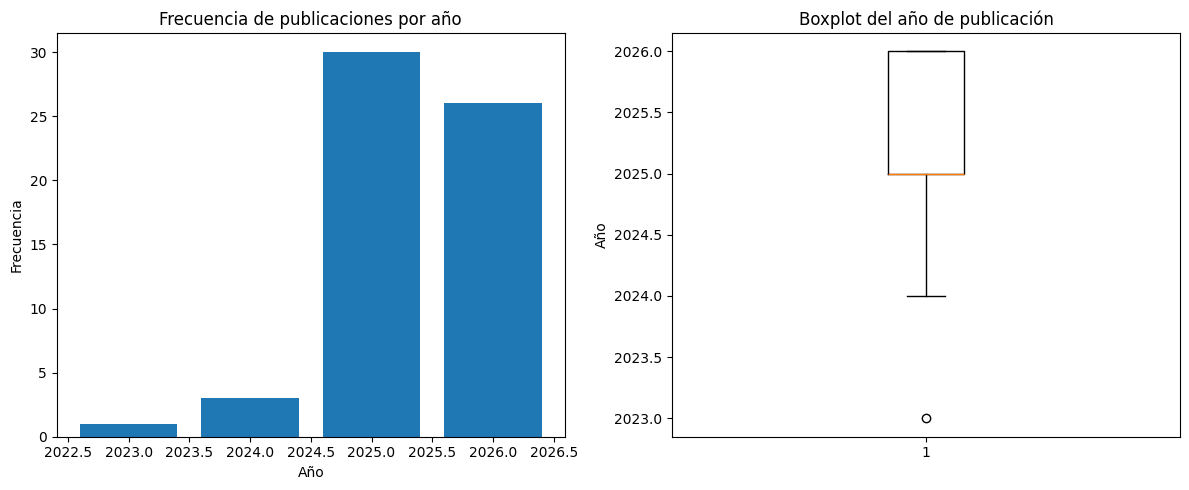

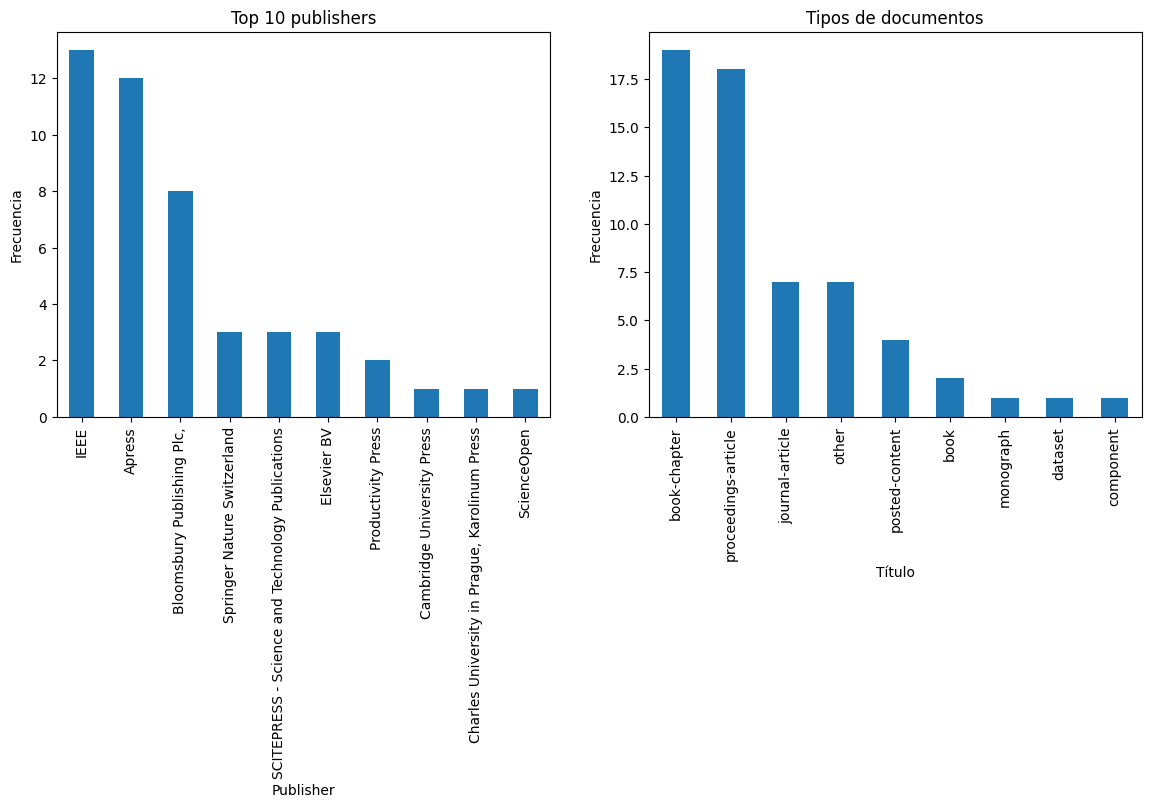

,year
count,60.000000
mean,2025.350000
std,0.659353
min,2023.000000
25%,2025.000000
50%,2025.000000
75%,2026.000000
max,2026.000000


In [14]:
###########################
# SOLUCIÓN: Resultados de la exploración
###########################
r_keywords.info()

freq = r_keywords["year"].value_counts().sort_index()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica frecuencia de publicaciones por año
ax[0].bar(freq.index, freq.values)
ax[0].set_xlabel("Año")
ax[0].set_ylabel("Frecuencia")
ax[0].set_title("Frecuencia de publicaciones por año")

# Gráfica bocplot por año de publicación
ax[1].boxplot(r_keywords["year"], vert=True)
ax[1].set_ylabel("Año")
ax[1].set_title("Boxplot del año de publicación")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica Top 10 publishers
r_keywords["publisher"].value_counts().head(10).plot(
    kind="bar",
    ax=ax[0]
)
ax[0].set_title("Top 10 publishers")
ax[0].set_ylabel("Frecuencia")
ax[0].set_xlabel("Publisher")

# Gráfica Top 10 títulos
r_keywords["type"].value_counts().plot(
    kind="bar",
    ax=ax[1]
)
ax[1].set_title("Tipos de documentos")
ax[1].set_ylabel("Frecuencia")
ax[1].set_xlabel("Título")

#plt.tight_layout()
plt.show()

r_keywords["year"].describe()

### 1.2: Extracción de datos de las entidades tipo author

<div style="background-color: #FFFF99; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

<b> Ejercicio C: (3 ptos.) </b>

<b>Objetivo:</b> Obtener metadatos de entidades tipo *author* y almacenar resultados en un dataframe.

<b>Requisito:</b> El dataframe deberá llamarse <i>r_authors</i>.

<b>Salida esperada:</b> Presentar al menos 5 filas aleatorias del dataframe creado.

</div>

<b> a. Preparar el request (importar libraries y definir parámetros generales para usar la API works) e implementar una función para realizar la llamada en función del parámetro enviado.</b>

Luego de la revisión de la documentación, crear una función para obtener información de las entidades de tipo *author*, que reciba como parámetro el valor leído desde el archivo proporcionado.

In [16]:
###########################
# SOLUCIÓN: Definir función que reciba parámetros (nombre de autores) para realizar la búsqueda.
###########################

endpoint = "https://api.crossref.org/v1/works"

def get_metadata_auth(authors):

    params = { #Se almacenan las palabras clave de autores (nombres de autores)
        "query": authors,
        "rows": 20
    }

    result = requests.get(endpoint, params=params) #Llamada de la API
    print(result)

    if result.status_code == 200:  # Si la solicitud es exitosa (código de estado 200)
        return result.json()["message"]["items"]
    else:
      print("Error en la solicitud:", result.status_code)

    return []

###########################
# SOLUCIÓN: Llamar a la función creada con cada valor de author para
# extraer sus metadatos
###########################

param_auth = kwDF2["name"][kwDF2["type"] == "author"]

for i in param_auth: get_metadata_auth(i)

<Response [200]>
<Response [200]>
<Response [200]>


<b> b. Procesar los datos extraídos y almacenarlos en un dataframe.</b>


In [24]:
###########################
# SOLUCIÓN: Procesar el json devuelto y almacenar resultados en un dataframe
###########################
data_auth = []

for autor in param_auth:
  items = get_metadata_auth(autor) #Llamada de la API por cada autor

  for i in items: #Se extrae información de las columnas
    title = i["title"][0] if i.get("title") else None
    doi = i.get("DOI")
    publisher = i.get("publisher")
    doc_type = i.get("type")
    year = None

    if "published-print" in i: #Se extrae el año de publicación en diferentes condiciones
      year = i["published-print"].get("date-parts")[0][0] if i["published-print"].get("date-parts") else None

    elif "published-online" in i:
      year = i["published-online"].get("date-parts")[0][0] if i["published-online"].get("date-parts") else None

    elif "created" in i:
      year = i["created"].get("date-parts")[0][0] if i["created"].get("date-parts") else None

    elif "published" in i:
      year = i["published"].get("date-parts")[0][0] if i["published"].get("date-parts") else None

    data_auth.append({"Author": autor, "title": title, "DOI": doi, "publisher": publisher, "type": doc_type, "year": year})

r_authors = pd.DataFrame(data_auth)

<Response [200]>
<Response [200]>
<Response [200]>


In [25]:
r_authors

,Author,title,DOI,publisher,type,year
0,Yael+Feldman-Maggor,Automated Identification and Validation of the...,10.35542/osf.io/rvmwq,Center for Open Science,posted-content,2023
1,Yael+Feldman-Maggor,Efficiency vs. effectiveness,10.20851/ll.v8.60,Adelaide University,journal-article,2026
2,Yael+Feldman-Maggor,Explainable AI for unsupervised machine learni...,10.35542/osf.io/3gqzk,Center for Open Science,posted-content,2024
3,Yael+Feldman-Maggor,AI for chemistry teaching: responsible AI and ...,10.1515/cti-2024-0014,Walter de Gruyter GmbH,journal-article,2024
4,Yael+Feldman-Maggor,Navigating the online learning journey by self...,10.1016/j.compedu.2024.105074,Elsevier BV,journal-article,2024
5,Yael+Feldman-Maggor,Integration of open educational resources in u...,10.1039/c5rp00184f,Royal Society of Chemistry (RSC),journal-article,2016
6,Yael+Feldman-Maggor,"ATOC: Amplification, Transformation, Opportuni...",10.5220/0014921200004021,SCITEPRESS - Science and Technology Publications,proceedings-article,2026
7,Yael+Feldman-Maggor,TECHNOLOGY ENHANCED ACCESSIBLE LEARNING (TEAL)...,10.21125/edulearn.2025.1323,IATED,proceedings-article,2025
8,Yael+Feldman-Maggor,Perspectives of Generative AI in Chemistry Edu...,10.1007/s10956-024-10147-3,Springer Science and Business Media LLC,journal-article,2025
9,Yael+Feldman-Maggor,Let them choose: Optional assignments and onli...,10.1016/j.iheduc.2022.100867,Elsevier BV,journal-article,2022


In [26]:
###########################
# SOLUCIÓN: Presentar/imprimir al menos 5 filas aleatorias de los datos extraídos.
###########################
r_authors.sample(5)


,Author,title,DOI,publisher,type,year
24,Suhail+Ahmad+Rana,Exploring the Role of Retrieval-Augmented Gene...,10.2139/ssrn.5357871,Elsevier BV,posted-content,2025
14,Yael+Feldman-Maggor,Are They Ready to Teach? Generative AI as a Me...,10.1007/s10956-024-10180-2,Springer Science and Business Media LLC,journal-article,2025
22,Suhail+Ahmad+Rana,AI Governance in Smart Grids and Industrial Au...,10.2139/ssrn.5509958,Elsevier BV,posted-content,2025
21,Suhail+Ahmad+Rana,Adversarial Artificial Intelligence in Industr...,10.2139/ssrn.6055035,Elsevier BV,posted-content,2026
50,Tania+Gentic,Translocal Misreadings: Eugeni d’Ors in Latin ...,10.1007/978-3-319-58208-5_10,Springer International Publishing,book-chapter,2017


<b> c. Exploración del dataset.</b>

Aplicar resúmenes de datos sobre el dataset creado. Elegir las mejores técnicas univariantes (estadísticas y gráficas), dependiendo del tipo de variable.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Author     60 non-null     object
 1   title      60 non-null     object
 2   DOI        60 non-null     object
 3   publisher  60 non-null     object
 4   type       60 non-null     object
 5   year       60 non-null     int64 
dtypes: int64(1), object(5)
memory usage: 2.9+ KB


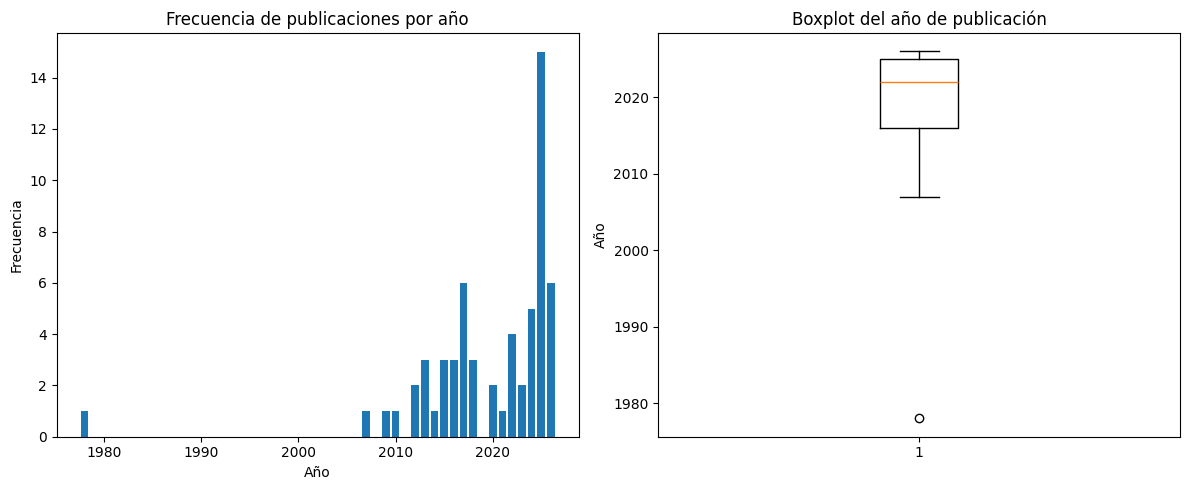

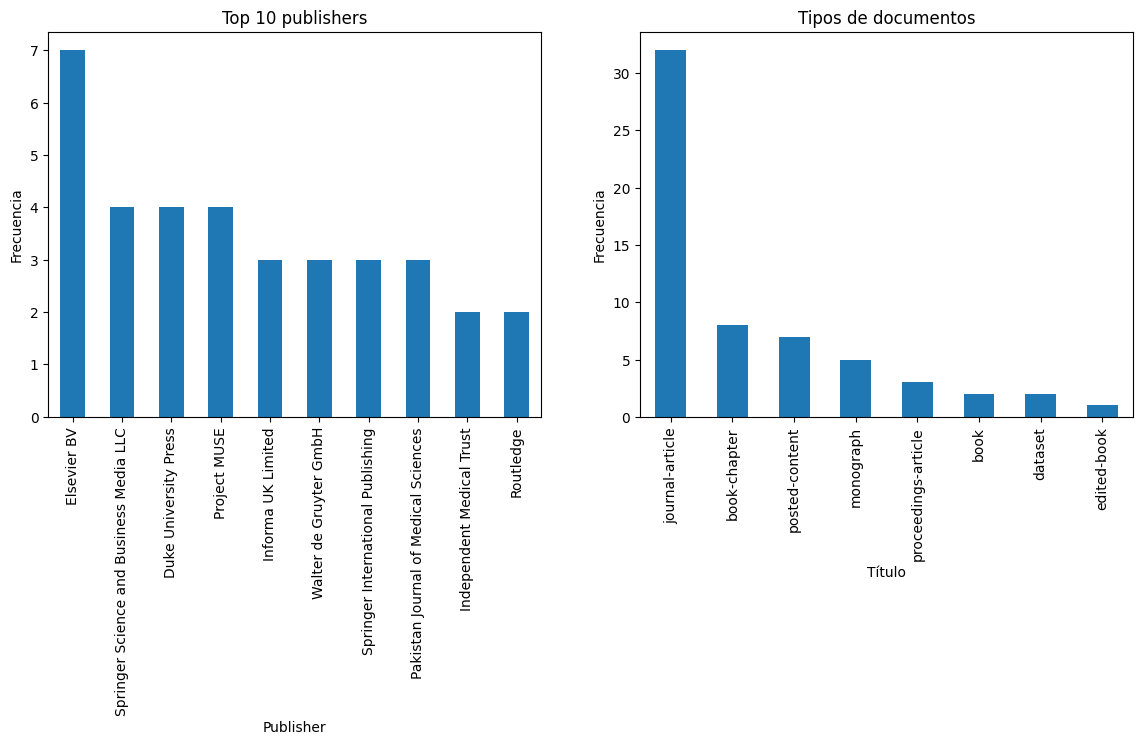

,year
count,60.000000
mean,2019.600000
std,7.535678
min,1978.000000
25%,2016.000000
50%,2022.000000
75%,2025.000000
max,2026.000000


In [27]:
###########################
# SOLUCIÓN: Resultados de la exploración
###########################
r_authors.info()

freq_auth = r_authors["year"].value_counts().sort_index()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica frecuencia de publicaciones por año
ax[0].bar(freq_auth.index, freq_auth.values)
ax[0].set_xlabel("Año")
ax[0].set_ylabel("Frecuencia")
ax[0].set_title("Frecuencia de publicaciones por año")

# Gráfica bocplot por año de publicación
ax[1].boxplot(r_authors["year"], vert=True)
ax[1].set_ylabel("Año")
ax[1].set_title("Boxplot del año de publicación")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica Top 10 publishers
r_authors["publisher"].value_counts().head(10).plot(
    kind="bar",
    ax=ax[0]
)
ax[0].set_title("Top 10 publishers")
ax[0].set_ylabel("Frecuencia")
ax[0].set_xlabel("Publisher")

# Gráfica Top 10 títulos
r_authors["type"].value_counts().plot(
    kind="bar",
    ax=ax[1]
)
ax[1].set_title("Tipos de documentos")
ax[1].set_ylabel("Frecuencia")
ax[1].set_xlabel("Título")

#plt.tight_layout()
plt.show()

r_authors["year"].describe()


## Fase 2: Integración de datos

<div style="background-color: #FFFF99; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

<b> Ejercicio D (3 ptos): Integración de datos obtenidos (tanto de keywords, como de authors) </b>

<b>Objetivo:</b> Crear un dataframe único donde consten los datos obtenidos con cada tipo de entidad.

<b>Requisitos:</b>

- A partir de la estructuras de datos <i> r_keywords </i> y <i> r_authors </i>, determinar cuáles de los atributos son comunes y cuáles son diferentes para crear una sola estructura tipo dataframe que almacene todos los datos extraídos.

<b>Salida esperada:</b> Presentar/imprimir un <i>sample</i> de 10 elementos que consten en el dataframe único.


</div>

In [35]:
######################
# SOLUCIÓN
######################

#Revisamos las columnas de los dataframes construidos
cols_keywords = set(r_keywords.columns)
cols_authors = set(r_authors.columns)
print(cols_keywords)
print(cols_authors)

#Revisamos los atributos que tienen en común y diferentes
print("Atributos comunes: ", cols_keywords & cols_authors)
print("Atributos diferentes: ", cols_keywords ^ cols_authors)

#Concatenación de los dataframes para dataframe unico
dataframe_unico = pd.concat([r_keywords, r_authors],
                     ignore_index=True,
                     sort=False)

dataframe_unico.sample(10)

dataframe_unico.to_csv("dataframe_unico.csv", index=False)

{'keyword', 'DOI', 'type', 'title', 'year', 'publisher'}
{'Author', 'DOI', 'type', 'title', 'year', 'publisher'}
Atributos comunes:  {'DOI', 'type', 'title', 'year', 'publisher'}
Atributos diferentes:  {'keyword', 'Author'}


### Exportar resultados a formato HTML

In [36]:
!jupyter nbconvert --pdf Lab1_API.ipynb

[NbConvertApp] WARNING | Unrecognized alias: 'pdf', it will have no effect.
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execu